1. Compute and report precision, recall, and F1-score for each model.
2. Plot a confusion matrix for each model.
3. Which model has the lowest recall? Is this the model you expected to be hardest based on your hazard analysis?
4. Based on a safety argument: what minimum recall would you require for the pedestrian model before considering deployment? Justify your threshold.

Installing seaborn for confusion matrix plotting

In [5]:
import sys
!{sys.executable} -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
NVIDIA GeForce RTX 3050 Laptop GPU


In [6]:
import torch
import torch.nn as nn

from torchvision import models, transforms

from torch.utils.data import Dataset, DataLoader

from PIL import Image

import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt

import seaborn as sns

Generic evaluation + confusion matrix function

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

In [8]:
transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
class CarlaDataset(Dataset):

    def __init__(self, csv_file, img_dir, label_column, transform=None):

        self.labels = pd.read_csv(csv_file)

        self.img_dir = img_dir

        self.label_column = label_column

        self.transform = transform


    def __len__(self):

        return len(self.labels)


    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = f"{self.img_dir}/{frame}.jpg"

        image = Image.open(img_path).convert("RGB")

        label = float(row[self.label_column])

        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

In [11]:
import os

os.chdir(r"C:\Projects\ML Safety Sose 26\data")

In [12]:
test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_vehicle',

    transform=transform
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False
)

## Vehicle Model Evaluation 

In [15]:
from torchvision.models import resnet18, ResNet18_Weights

vehicle_model = resnet18(weights=ResNet18_Weights.DEFAULT)

vehicle_model.fc = nn.Linear(
    vehicle_model.fc.in_features,
    1
)

vehicle_model.load_state_dict(
    torch.load('vehicle_model.pth')
)

vehicle_model = vehicle_model.to(device)

vehicle_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
def evaluate_and_plot(model, test_loader):

    all_preds = []

    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.sigmoid(outputs)

            preds = (preds > 0.5).float()

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.numpy())


    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    print("Precision:", precision)

    print("Recall:", recall)

    print("F1-score:", f1)


    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

Precision: 0.9863013698630136
Recall: 0.8
F1-score: 0.8834355828220859


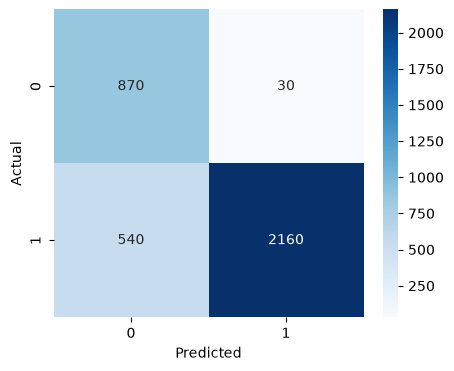

In [17]:
evaluate_and_plot(vehicle_model, test_loader)

## Pedestrian Model Evaluation

In [18]:
ped_test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_pedestrian',

    transform=transform
)

ped_test_loader = DataLoader(

    ped_test_dataset,

    batch_size=32,

    shuffle=False
)

In [19]:
from torchvision.models import resnet18, ResNet18_Weights

pedestrian_model = resnet18(weights=ResNet18_Weights.DEFAULT)

pedestrian_model.fc = nn.Linear(
    pedestrian_model.fc.in_features,
    1
)

pedestrian_model.load_state_dict(
    torch.load('pedestrian_model.pth')
)

pedestrian_model = pedestrian_model.to(device)

pedestrian_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Precision: 0.5720338983050848
Recall: 0.19121813031161472
F1-score: 0.28662420382165604


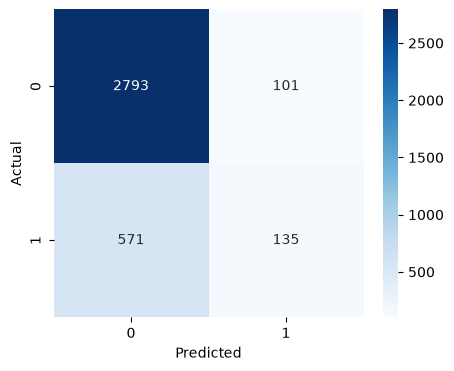

In [20]:
evaluate_and_plot(
    pedestrian_model,
    ped_test_loader
)

## Traffic Light Model Evaluation

In [21]:
traffic_test_dataset = CarlaDataset(

    csv_file='test/labels.csv',

    img_dir='test/rgb-front',

    label_column='has_traffic_light',

    transform=transform
)

traffic_test_loader = DataLoader(

    traffic_test_dataset,

    batch_size=32,

    shuffle=False
)

In [22]:
from torchvision.models import resnet18, ResNet18_Weights

traffic_model = resnet18(weights=ResNet18_Weights.DEFAULT)

traffic_model.fc = nn.Linear(
    traffic_model.fc.in_features,
    1
)

traffic_model.load_state_dict(
    torch.load('traffic_light_model.pth')
)

traffic_model = traffic_model.to(device)

traffic_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Precision: 0.9155937052932761
Recall: 0.9907120743034056
F1-score: 0.9516728624535316


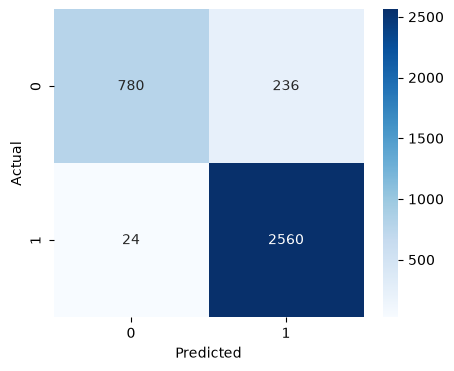

In [23]:
evaluate_and_plot(
    traffic_model,
    traffic_test_loader
)